# Sampling-free magnification PDF of stochastic weak lensing

This notebook computes the weak-lensing magnification distribution
$\mathrm{d}P/\mathrm{d}\ln\mu$ of a point source at redshift $z_s$, for a given
cosmology, **without sampling any lens configuration**. The lens model is the
stochastic model of Vaskonen (2026, [arXiv:2601.06023](https://arxiv.org/abs/2601.06023))
and FLUMEN (Baltabay et al. 2026, [arXiv:2609.21806](https://arxiv.org/abs/2609.21806)):
field halos with elliptical projections, filaments, subhalos, and the clustering of
all of them. The Monte Carlo realises this population ray by ray. Here its law is
computed directly: the distortion $\boldsymbol X = (\kappa,\gamma_1,\gamma_2)$ along a
line of sight is a compound-Poisson process in the lens redshift. Its characteristic
function is the exponential of a deterministic integral over the lens population, and
one Fourier inversion turns that into $P(\mu)$.

The notebook follows the solver stage by stage, in the order of the paper draft
(`paper/main_v1.tex` in the parent project):

1. cosmology: linear power, $\sigma(M)$, mass function, concentrations;
2. single lenses: truncated NFW halos, ellipticity, filaments, subhalos;
3. the master equation and the lens-redshift quadrature;
4. the clustering term;
5. the population build and the exponent $\ln\Phi(\boldsymbol k)$;
6. inversion to $p(\kappa,\gamma)$ and $\mathrm{d}P_S/\mathrm{d}\ln\mu$;
7. dependence on $z_s$ and $\sigma_8$.

**The default lens model, and how it differs from the Monte Carlo engine.**
Halos are truncated at their virial radii and integrated over the whole lens plane,
so there is no convergence threshold $\kappa_{\rm thr}$, no outer radius $r_{\max}$ and
no Gaussian treatment of faint lenses. Clustering is the linear-bias pair term with
the 3D linear correlation function, not the engine's lognormal modulation of the
counts along a 1D field. The lens-redshift integral runs over all of $[0, z_s]$
(midpoint rule). Because of these choices the PDF is not meant to reproduce the
engine's Monte Carlo bin by bin: at $z_s \lesssim 1$ its variance is a few per cent
lower and its skewness slightly higher.

**No physics is written in this notebook.** Every cell calls the solver in `src/`:

| module | provides |
|---|---|
| `pipeline.py` | `run()`: the whole chain; `make_cosmology()` |
| `sgl.py` | `Cosmology` (EH98 transfer, growth, $\sigma(M)$, Sheth-Tormen, Ludlow+16 $c(M)$, $\Sigma_{\rm cr}$), projected NFW |
| `sgl_full.py` | truncated NFW, pseudo-elliptical lensing, bias, $z$ shells, population cells `Cells`, the exponent `Lam`, inversion `invert` |
| `filaments.py` | filament mass function and cylinder profile |
| `subhalos.py`, `subhalos_exact.py` | subhalo population and the exact decorated-host quadrature |

The inputs are in `config.py`. Change one there and rerun
`python scripts/build_notebook.py`; nothing in the notebook itself needs editing.

In [1]:
import os, sys, time
from pathlib import Path

# silence libomp's "omp_set_nested deprecated" notices from the build workers
os.environ.setdefault("KMP_WARNINGS", "0")

REPO = Path.cwd()
while not (REPO / "src" / "pipeline.py").is_file():
    REPO = REPO.parent
sys.path[:0] = [str(REPO), str(REPO / "src")]

import numpy as np
import matplotlib.pyplot as plt

import config
import pipeline
import sgl
import sgl_full as F
import filaments as fil
import subhalos

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 10})
print("solver loaded from", REPO / "src")
print(f"z_s = {config.ZS}, cosmology = {config.COSMO}, config = {config.CONFIG!r}, "
      f"nproc = {config.NPROC}")

solver loaded from /Users/baltabay/Desktop/sGL_analytic/src
z_s = 1.0, cosmology = {'h': 0.674, 'Om': 0.315, 's8': 0.811}, config = 'full', nproc = 10


## 1. Cosmology: linear power, $\sigma(M)$, halo abundance

**Linear power.** $P_{\rm lin}(k,z) = D(z)^2 A\,k^{n_s} T(k)^2$, with the
Eisenstein & Hu (1998, [astro-ph/9709112](https://arxiv.org/abs/astro-ph/9709112))
transfer function including baryon wiggles (`sgl.Cosmology._T_eh98`). $D(z)$ is the exact
linear growth of flat $\Lambda$CDM, normalised to $D(0)=1$ (`Cosmology.D`). The amplitude $A$
is fixed by $\sigma_8$ measured with a real-space top hat of radius $8\,h^{-1}$ Mpc,
as in the engine.

**Variance of the mass field.** Smoothed with the engine's smooth-$k$ filter
(`Cosmology._Ws`),
$$\sigma^2(M,z) = \frac{D(z)^2}{2\pi^2}\int\!\mathrm dk\,k^2 P_{\rm lin}(k,0)\,W(kR)^2,\qquad
W(x) = \frac{1}{1+(0.43\,x)^6},\qquad M = \tfrac{4\pi}{3}\bar\rho_m R^3 .$$

**Halo mass function.** Sheth & Tormen (1999, [astro-ph/9901122](https://arxiv.org/abs/astro-ph/9901122)),
with $\nu = \delta_c^2/\sigma^2$, $(p,q) = (0.3, 0.8)$, $\delta_c = 1.686$ and $A$ fixed by $\int f\,\mathrm d\nu = 1$
(`Cosmology.dndlnM`):
$$\frac{\mathrm d\bar n}{\mathrm d\ln M} = \frac{\bar\rho_m}{M}\,A\left[1+(q\nu)^{-p}\right]
\sqrt{\frac{q\nu}{2\pi}}\,e^{-q\nu/2}\left(-2\,\frac{\mathrm d\ln\sigma}{\mathrm d\ln M}\right).$$
Masses are $M\equiv M_{200}$ (200 times the critical density).

**Concentration.** Ludlow et al. (2016, [arXiv:1601.02624](https://arxiv.org/abs/1601.02624)),
a fit in peak height $\delta_c/\sigma(M)$, so $c$ moves with $\sigma_8$ (`Cosmology.conc`).
`pipeline.make_cosmology` builds the `Cosmology` with exactly these choices.

h = 0.674, Om = 0.315, Ob = 0.0493, ns = 0.965
sigma_8 (top hat, the anchor) = 0.8110
D(z=1) = 0.6068,  D(z=3) = 0.3154


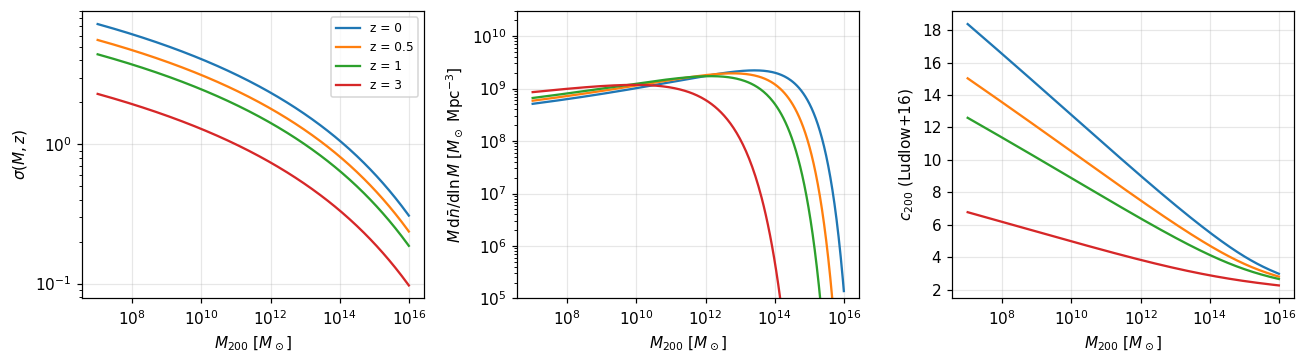

In [2]:
cos = pipeline.make_cosmology(config.COSMO)
print(f"h = {cos.h}, Om = {cos.Om}, Ob = {cos.Ob}, ns = {cos.ns}")
print(f"sigma_8 (top hat, the anchor) = {cos.sigma_tophat8():.4f}")
print(f"D(z=1) = {cos.D(1.0):.4f},  D(z=3) = {cos.D(3.0):.4f}")

M = np.logspace(7, 16, 300)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for z in (0.0, 0.5, 1.0, 3.0):
    ax[0].loglog(M, cos.sigmaM(M, z), label=f"z = {z:g}")
    ax[1].loglog(M, M * cos.dndlnM(M, z), label=f"z = {z:g}")
    ax[2].semilogx(M, cos.conc(M, z, cos.h), label=f"z = {z:g}")
ax[0].set(xlabel=r"$M_{200}$ [$M_\odot$]", ylabel=r"$\sigma(M,z)$")
ax[1].set(xlabel=r"$M_{200}$ [$M_\odot$]", ylabel=r"$M\,\mathrm{d}\bar n/\mathrm{d}\ln M$ [$M_\odot$ Mpc$^{-3}$]",
          ylim=(1e5, 3e10))
ax[2].set(xlabel=r"$M_{200}$ [$M_\odot$]", ylabel=r"$c_{200}$ (Ludlow+16)")
ax[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 2. Lensing efficiency

A lens of surface density $\Sigma$ at redshift $z$ produces the convergence
$\kappa = \Sigma/\Sigma_{\rm cr}$, with the critical surface density (flat universe,
physical angular-diameter distances; `Cosmology.Sigma_cr`)
$$\Sigma_{\rm cr}(z, z_s) = \frac{c^2}{4\pi G}\,\frac{D_A(z_s)}{D_A(z)\,D_A(z,z_s)} .$$
Every jump of the process below is proportional to $1/\Sigma_{\rm cr}$, which vanishes at the
observer and at the source and peaks in between.

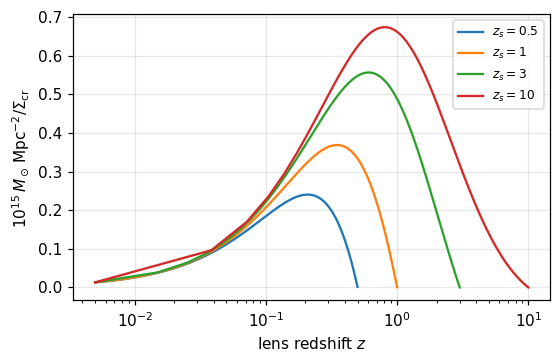

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
for zs in config.ZS_LIST:
    zl = np.linspace(0.005, zs - 1e-3, 300)
    ax.plot(zl, [1e15 / cos.Sigma_cr(z, zs) for z in zl], label=f"$z_s = {zs:g}$")
ax.set(xlabel="lens redshift $z$", ylabel=r"$10^{15}\,M_\odot\,\mathrm{Mpc}^{-2}/\Sigma_{\rm cr}$",
       xscale="log")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 3. A single halo: the truncated NFW lens

Each halo has an NFW profile (Navarro, Frenk & White 1997, [astro-ph/9611107](https://arxiv.org/abs/astro-ph/9611107)),
$\rho = \rho_s/[(r/r_s)(1+r/r_s)^2]$, with $r_s = r_{200}/c$. In units of the dimensionless
radius $x = r/r_s$ in the lens plane and the amplitude $\kappa_s = \rho_s r_s/\Sigma_{\rm cr}$
(`Cosmology.nfw_params`), the untruncated projection is (Wright & Brainerd 2000,
[astro-ph/9908213](https://arxiv.org/abs/astro-ph/9908213); `sgl.kappa_gamma`)
$$\kappa = 2\kappa_s F(x),\qquad \bar\kappa = \frac{4\kappa_s\,h(x)}{x^2},\qquad \gamma = \bar\kappa - \kappa,$$
$$F(x) = \frac{1 - A(x)/\sqrt{|1-x^2|}}{x^2-1},\qquad h(x) = \ln\frac x2 + \frac{A(x)}{\sqrt{|1-x^2|}},$$
with $A = \operatorname{arccosh}(1/x)$ for $x<1$ and $\arccos(1/x)$ for $x>1$.

**Virial truncation (default).** Unlike the engine, the profile is cut sharply in
3D at the virial radius $r_{\rm vir} = \eta\,r_{200}$ ($x_t = \eta c$, with the Bryan & Norman
overdensity; `subhalos._eta`). The projected convergence then vanishes beyond $x_t$, and
the shear outside is that of a point mass with the virial mass,
$\gamma = 4\kappa_s\,\mu(x_t)/x^2$ with $\mu(y) = \ln(1+y) - y/(1+y)$. Inside, the projection of the
mass beyond $r_{\rm vir}$ is subtracted in closed form (`sgl_full.nfw_trunc_kg`). Truncation makes
the projected mass of every halo finite, which is what the clustering term of Sec. 6 needs.

M200 = 1.0e+14 Msun at z = 0.4: c = 4.85, r_s = 175.1 kpc, kappa_s = 0.1009 (z_s = 1.0), x_t = r_vir/r_s = 5.78


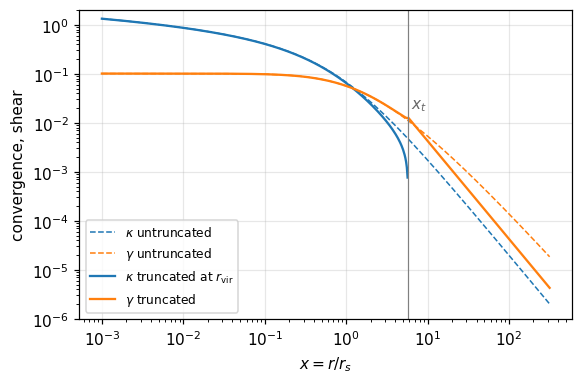

In [4]:
Mh, zl = config.EXAMPLE_M, config.EXAMPLE_ZL
C_, rs, ks, fC = cos.nfw_params(Mh, zl, config.ZS)
xt = subhalos._eta(cos, C_, zl) * C_
print(f"M200 = {Mh:.1e} Msun at z = {zl}: c = {C_:.2f}, r_s = {rs*1e3:.1f} kpc, "
      f"kappa_s = {ks:.4f} (z_s = {config.ZS}), x_t = r_vir/r_s = {xt:.2f}")

x = np.logspace(-3, 2.5, 600)
k_u, g_u = sgl.kappa_gamma(np.ascontiguousarray(x), ks)
k_t, g_t = F.nfw_trunc_kg(x, ks, xt)
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.loglog(x, k_u, "C0--", lw=1, label=r"$\kappa$ untruncated")
ax.loglog(x, g_u, "C1--", lw=1, label=r"$\gamma$ untruncated")
ax.loglog(x, np.where(k_t > 0, k_t, np.nan), "C0", label=r"$\kappa$ truncated at $r_{\rm vir}$")
ax.loglog(x, g_t, "C1", label=r"$\gamma$ truncated")
ax.axvline(xt, color="0.5", lw=0.8); ax.text(xt * 1.1, 2e-2, r"$x_t$", color="0.4")
ax.set(xlabel=r"$x = r/r_s$", ylabel="convergence, shear", ylim=(1e-6, 2))
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 4. The master equation

A light ray collects its distortion $\boldsymbol X = (\kappa,\gamma_1,\gamma_2) = \sum_j \boldsymbol q_j$ one lens at a
time (Born approximation, additive distortions). Take the lens redshift $z$ as the time
variable. A lens with parameters $\theta$ (mass, position in the lens plane relative to the
ray, orientation, ...) appears between $z$ and $z+\mathrm dz$ with probability
$n(z,\theta)\,\mathrm dz\,\mathrm d\theta$ and adds the jump $\boldsymbol q(z,\theta)$. The distribution of the distortion
accumulated up to $z$ then obeys the **compensated Kolmogorov-Feller equation**
$$\partial_z P(\boldsymbol X;z) = \int\!\mathrm d\theta\,n(z,\theta)\Big[P(\boldsymbol X-\boldsymbol q;z) - P(\boldsymbol X;z) + q_a\,\partial_a P(\boldsymbol X;z)\Big],\qquad P(\boldsymbol X;0) = \delta_D(\boldsymbol X).$$
The last term is a drift that keeps $\langle\boldsymbol X\rangle = 0$: distortions are measured from the mean
of the modelled lenses, and the remaining matter is smooth.

**Fourier space.** Plane waves are its eigenfunctions. With $\tilde P(\boldsymbol k;z) = \int\mathrm d^3X\,e^{i\boldsymbol k\cdot\boldsymbol X}P$,
$$\partial_z \tilde P = \ell(\boldsymbol k;z)\,\tilde P,\qquad
\ell(\boldsymbol k;z) = \int\!\mathrm d\theta\,n\left[e^{i\boldsymbol k\cdot\boldsymbol q} - 1 - i\boldsymbol k\cdot\boldsymbol q\right],\qquad
\boxed{\;\Phi_{\rm lens}(\boldsymbol k) = \exp\!\Big[\int_0^{z_s}\!\mathrm dz\,\ell(\boldsymbol k;z)\Big]\;}$$
This is the Lévy-Khintchine form of a compensated compound-Poisson process. All its cumulants
are exact, $\langle X_{a_1}\cdots X_{a_n}\rangle_c = \int\mathrm dz\int\mathrm d\theta\,n\,q_{a_1}\cdots q_{a_n}$ for $n\ge2$. Truncating at
$n=2$ would give the Gaussian (Fokker-Planck, power-spectrum) approximation, which misses the
skewed shape of $P(\mu)$.

**Isotropy.** A circular lens at polar angle $\phi$ has $\gamma_1 + i\gamma_2 = \gamma\,e^{2i\phi}$. Averaging over $\phi$
gives $J_0(k_\gamma\gamma)$, $k_\gamma = (k_1^2+k_2^2)^{1/2}$, so $\ell$ depends only on $(k_\kappa, k_\gamma)$. For spherical halos,
$$\ell(k_\kappa,k_\gamma;z) = \frac{2\pi c\,(1+z)^2}{H(z)}\int\!\mathrm d\ln M\,\frac{\mathrm d\bar n}{\mathrm d\ln M}\int_0^\infty\! r\,\mathrm dr
\Big[e^{ik_\kappa\kappa(r)}J_0\big(k_\gamma\gamma(r)\big) - 1 - ik_\kappa\kappa(r)\Big],$$
where $(1+z)^2 c/H$ converts the comoving density and physical lens-plane area into a rate per unit redshift.
The integral runs over the whole lens plane. The faint lenses at large $r$ are numerous, but
their jumps are small and the integrand is $O(k^2q^2)$, so it converges with no threshold.
Numerically the radial integral stops where the halo's shear tail falls below
$\kappa = 10^{-8}$ (`kap_floor`), a convergence limit rather than a model parameter.

### Lens-redshift quadrature

The $z$ integral is evaluated on shells whose edges are the engine's 103 log-spaced lens
redshifts below $z_s$, plus $0$ and $z_s$, so the whole interval $[0,z_s]$ is covered. Each shell
is integrated with its midpoint (`sgl_full.z_shells(zs, "midpoint")`, the default). For comparison,
the engine's own rule puts one node at each shell's upper edge and drops $[0, 0.01]$ and the last
partial shell, which costs about 3% of the lensing variance. A 2-point Gauss rule per shell changes
the clipped variance by $<10^{-5}$ relative to midpoint, so the midpoint rule is converged.

In [5]:
segs, tasks, zn = F.z_shells(config.ZS, "midpoint")
segs_e, tasks_e, _ = F.z_shells(config.ZS, "engine")
print(f"midpoint: {len(segs)} shells covering [{segs[0][0]:.3f}, {segs[-1][1]:.3f}]")
print(f"engine  : {len(segs_e)} shells covering [{segs_e[0][0]:.3f}, {segs_e[-1][1]:.3f}]")
print("first nodes (z, dz):", [(round(float(t[0][1]), 4), round(float(t[0][2]), 4)) for t in tasks[:4]])

midpoint: 67 shells covering [0.000, 1.000]
engine  : 65 shells covering [0.010, 0.933]
first nodes (z, dz): [(0.005, 0.01), (0.0104, 0.0007), (0.0111, 0.0008), (0.0119, 0.0008)]


## 5. The full lens population

Each ingredient of the model changes one element of the master equation:
ellipticity and subhalos change the jump, filaments add a second Poisson population,
and clustering correlates the lenses (Sec. 6).

### 5a. Elliptical halos

Each halo is projected as a pseudo-elliptical NFW lens (Golse & Kneib 2002,
[astro-ph/0112138](https://arxiv.org/abs/astro-ph/0112138)), with the profile evaluated at the elliptical radius
$x_\epsilon^2 = (1-\epsilon)x_1^2 + (1+\epsilon)x_2^2$ (`sgl_full.kappagamma_eps`):
$$\kappa_\epsilon = \kappa(x_\epsilon) + \epsilon\cos 2\psi_\epsilon\,\gamma(x_\epsilon),\qquad
\gamma_\epsilon^2 = \gamma^2 + 2\epsilon\cos2\psi_\epsilon\,\gamma\kappa + \epsilon^2\left(\kappa^2 - \cos^2 2\psi_\epsilon\,\gamma^2\right),$$
with the engine's $\cos^2$ form of the $\epsilon^2$ term. The ellipticity follows the $N$-body fit of
Allgood et al. (2006, [astro-ph/0508497](https://arxiv.org/abs/astro-ph/0508497)) as in the engine
(`sgl_full.epsilon_NFW`): $s = 0.54\,(M/M_*)^{-0.05}$, $\epsilon = (1-s)/(1+s)$, with $\sigma(M_*) = \delta_c/D(z)$. The orientation
is uniform, so the halo term of $\ell$ gains one quadrature over the angle $\psi$ between the
ray and the major axis (12 angles):
$$\int_0^\infty r\,\mathrm dr\int_0^{2\pi}\frac{\mathrm d\psi}{2\pi}\Big[e^{ik_\kappa\kappa(r,\psi)}J_0\big(k_\gamma\gamma(r,\psi)\big) - 1 - ik_\kappa\kappa(r,\psi)\Big].$$
Inside the truncation radius the elliptical profile is that of the truncated halo. Outside it,
$\kappa = 0$ and the shear is the point-mass monopole.

M = 1.0e+14 Msun, z = 0.4: M* = 2.24e+12 Msun, epsilon = 0.383


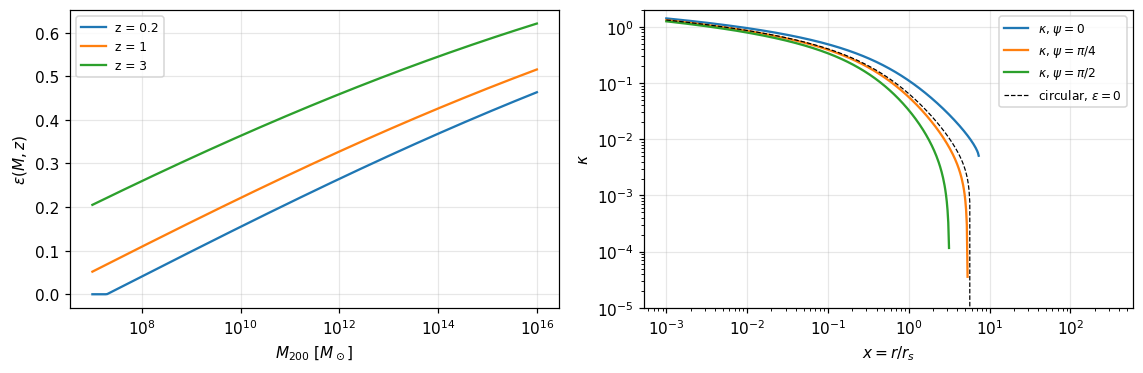

In [6]:
eps = F.epsilon_NFW(cos, Mh, zl)
print(f"M = {Mh:.1e} Msun, z = {zl}: M* = {F.Mstar(cos, zl):.2e} Msun, epsilon = {eps:.3f}")
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
for zz in (0.2, 1.0, 3.0):
    ax[0].semilogx(M, F.epsilon_NFW_vec(cos, M, zz), label=f"z = {zz:g}")
ax[0].set(xlabel=r"$M_{200}$ [$M_\odot$]", ylabel=r"$\epsilon(M,z)$"); ax[0].legend(fontsize=8)
for psi, lab in ((0.0, "0"), (np.pi / 4, r"\pi/4"), (np.pi / 2, r"\pi/2")):
    k_e, g_e = F.kappagamma_eps(eps, ks, x, np.full_like(x, psi), xt=xt)
    ax[1].loglog(x, np.where(k_e > 0, k_e, np.nan), label=rf"$\kappa$, $\psi = {lab}$")
ax[1].loglog(x, k_t, "k--", lw=0.8, label=r"circular, $\epsilon = 0$")
ax[1].set(xlabel=r"$x = r/r_s$", ylabel=r"$\kappa$", ylim=(1e-5, 2)); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

### 5b. Filaments

Filaments are a second Poisson population, placed independently of the halos and
correlated with them only through clustering. Following the engine (`filaments.py`): a filament of
mass $M$ is a cylinder of radius $r_F = (M/10^{14}M_\odot)^{1/3}$ Mpc and length $L = 20\,r_F$, inclined at a
uniformly distributed angle $\varphi$ to the sky (`filaments.filament_params`). Its abundance is the
excursion-set mass function with the flat barrier $(p,q) = (0, 0.7)$ (Sheth, Mo & Tormen 2001,
[astro-ph/9907024](https://arxiv.org/abs/astro-ph/9907024); `filaments.dndlnM_fil`). Its lensing is circular about
the filament position (`filaments.kappa_gamma_cyl`, $u = r/r_F$):
$$\kappa_f = \frac{2\pi\kappa_0}{\sqrt{1+u^2}}\ (u\le1),\qquad \gamma_f = \frac{4\pi\kappa_0}{\sqrt{1+u^2}+1} - \kappa_f,\qquad
\kappa_0 = \frac{r_F\rho_s}{\Sigma_{\rm cr}},\quad \rho_s = \frac{14.4\,\rho_{c,0}\,L}{\max(2r_F, |\cos\varphi|L)}.$$
The filament term of $\ell$ integrates over the whole cross section ($u\le1$) and over $\varphi$. Because the cylinder
edge is sharp, $\gamma_f$ jumps by $\kappa_f(1)$ at $u = 1$ (the engine's profile, kept as is).

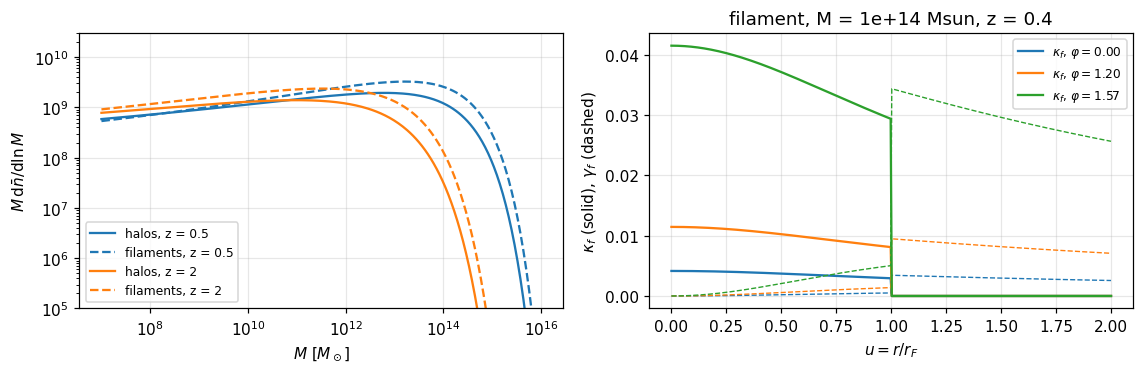

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
for zz in (0.5, 2.0):
    ax[0].loglog(M, M * cos.dndlnM(M, zz), f"C{int(zz>1)}", label=f"halos, z = {zz:g}")
    ax[0].loglog(M, M * fil.dndlnM_fil(cos, M, zz), f"C{int(zz>1)}--", label=f"filaments, z = {zz:g}")
ax[0].set(xlabel=r"$M$ [$M_\odot$]", ylabel=r"$M\,\mathrm{d}\bar n/\mathrm{d}\ln M$", ylim=(1e5, 3e10))
ax[0].legend(fontsize=8)
u = np.linspace(0, 2, 400)
for ph in (0.0, 1.2, np.pi / 2):
    rF, k0 = fil.filament_params(cos, Mh, zl, config.ZS, ph)
    kf, gf = fil.kappa_gamma_cyl(u, k0)
    ax[1].plot(u, kf, label=rf"$\kappa_f$, $\varphi = {ph:.2f}$")
    ax[1].plot(u, gf, "--", color=ax[1].lines[-1].get_color(), lw=0.9)
ax[1].set(xlabel=r"$u = r/r_F$", ylabel=r"$\kappa_f$ (solid), $\gamma_f$ (dashed)",
          title=f"filament, M = {Mh:.0e} Msun, z = {zl}")
ax[1].legend(fontsize=8); fig.tight_layout(); plt.show()

### 5c. Subhalos: the decorated host

Subhalos are attached to their hosts, so a host and its subhalos enter as **one composite
lens** (a Neyman-Scott cluster process, Neyman & Scott 1952). At fixed host mass $M$, redshift and
ray offset, the clumps are a Poisson population (FLUMEN's model 5; `subhalos.SubhaloModel.host`):
$$\frac{\mathrm dN}{\mathrm d\ln\psi} = g\,\psi^{\alpha}\,e^{-\beta\psi^{\omega}},\qquad \psi = \frac{m}{M_{\rm vir}}\in\Big[\frac{10^7M_\odot}{M_{\rm vir}},1\Big],\qquad
(\alpha,\beta,\omega) = (-0.82, 50, 4),$$
with the normalisation $g$ fixed by the bound mass fraction $f_s(M,z)$ of Jiang & van den Bosch
(formation redshift from the half-mass barrier crossing; `SubhaloModel.fs`). $f_s$ normalises the clumps with
$\psi\ge10^{-4}$; the population then extends down to $m = 10^7M_\odot$, so in massive hosts the total clump mass
fraction exceeds $f_s$. Clump positions follow the
host's NFW density times $B(x) = [1+(x/x_0)^{-2.5}]^{-1/2}$, $x_0 = 0.86\,r_{\rm vir}/r_{200}$, projected along the line of sight.
Each clump is an NFW halo with its virial mass $m$ and a Ludlow+16 concentration, truncated at its own
virial radius. It contributes when the ray passes inside that radius.

The rendered clump mass is removed from the smooth host: with $S = \sum_c m_c/v_r$ ($v_r = M_{\rm vir}/M_{200}$),
the host is rebuilt at $M_{\rm eff} = \max(M - S, 10^7 M_\odot)$, keeping its physical truncation radius, and the composite
jump is $\boldsymbol Q_h = \boldsymbol q_h(M_{\rm eff}) + \sum_c\boldsymbol q_c$. The single-halo factor $e^{ik_\kappa\kappa_h}J_0(k_\gamma\gamma_h)$ in $\ell$ becomes
$$\big\langle e^{i\boldsymbol k\cdot\boldsymbol Q_h}\big\rangle_{\rm sub} = \Big\langle e^{ik_\kappa[\kappa_h(M_{\rm eff}) + K]}\,J_0(k_\gamma\Gamma)\Big\rangle_{\rm sub},\qquad
\ln\big\langle e^{i(tK+uS)}\big\rangle = \int\mathrm d\nu\Big[e^{i(t\kappa_c + u\,m_c/v_r)} - 1\Big],$$
with $K = \sum_c\kappa_c$ and $\Gamma$ the magnitude of the total shear. The exact joint cumulants of $(K, S)$ from the
Poisson law define a deterministic 3-node $\times$ 3-node Gauss quadrature of this average
(`subhalos_exact.ExactSector.host_cells_moments`). $\Gamma$ is taken as its conditional rms at fixed $(K,S)$, including the
correlation between host and clump shear directions.

host table at z = 0.404:
 M200 [Msun]     f_s  <N_clump>  sum m / M_vir  (all clumps m >= 1e7 Msun)
    1.10e+11   0.089       68.3          0.089
    1.12e+12   0.105      547.4          0.116
    1.15e+13   0.128     4535.1          0.150
    1.18e+14   0.163    39292.7          0.199
    1.20e+15   0.220   362406.6          0.276


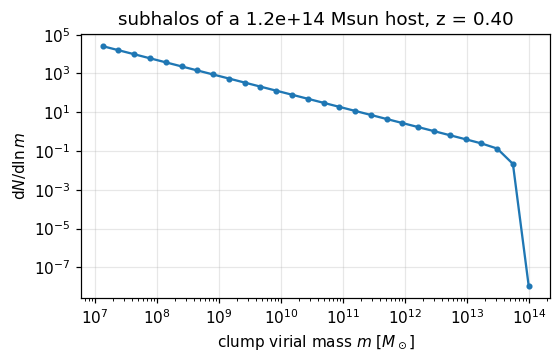

In [8]:
sub = subhalos.SubhaloModel(cos, config.ZS, None, sector="exact", clump_edge="rvir",
                            exact_kw=dict(method="moments"))
zg, Mg = F.engine_grids()
jz = int(np.argmin(abs(zg - zl)))
print(f"host table at z = {zg[jz]:.3f}:")
print(f"{'M200 [Msun]':>12s} {'f_s':>7s} {'<N_clump>':>10s} {'sum m / M_vir':>14s}  (all clumps m >= 1e7 Msun)")
for jM in np.searchsorted(Mg, [1e11, 1e12, 1e13, 1e14, 1e15]):
    h = sub.host(jz, int(jM))
    if h is None:
        continue
    print(f"{h['M']:12.2e} {h['f']:7.3f} {h['dN'].sum():10.1f} {np.sum(h['dN']*h['m'])/(h['M']*h['vr']):14.3f}")

h = sub.host(jz, int(np.searchsorted(Mg, Mh)))
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.loglog(h["m"], h["dN"] / np.log(h["m"][1] / h["m"][0]), "o-", ms=3)   # dN per ln-psi bin
ax.set(xlabel=r"clump virial mass $m$ [$M_\odot$]", ylabel=r"$\mathrm{d}N/\mathrm{d}\ln m$",
       title=f"subhalos of a {h['M']:.1e} Msun host, z = {h['z']:.2f}")
fig.tight_layout(); plt.show()

## 6. Clustering: the two-point term

Correlations between lenses change the exponent rather than the single-lens jump. For a general
point process, $\ln\Phi_{\rm lens} = \Psi_1 + \Psi_2 + \dots$, where $\Psi_1 = \int\mathrm dz\,\ell$ is the
independent-lens term above and
$$\Psi_2(\boldsymbol k) = \frac12\int\mathrm dz_1\mathrm d\theta_1\,\mathrm dz_2\mathrm d\theta_2\;n_1n_2\,\xi_{12}\,F_1(\boldsymbol k)F_2(\boldsymbol k),\qquad
F_p = \big\langle e^{i\boldsymbol k\cdot\boldsymbol Q_p}\big\rangle_{\rm sub} - 1 .$$
$F$ is **not** compensated here: the compensation belongs to $\Psi_1$, and compensating $F$ would remove
the fluctuation of the mean distortion caused by correlated lens counts. The default keeps $\Psi_2$ with
linear bias and the 3D linear correlation function,
$$\xi_{12} = b_1b_2\,D(z_1)D(z_2)\,\xi_{\rm lin}(|\boldsymbol x_1-\boldsymbol x_2|;0),$$
using the peak-background-split bias of each mass function (`sgl_full.halo_bias`, `sgl_full.fil_bias`;
subhalos carry their host's bias):
$$b_h = 1 + \frac{q\nu-1}{\delta_c} + \frac{2p}{\delta_c[1+(q\nu)^p]}\ \ (p,q = 0.3, 0.8),\qquad b_f = 1 + \frac{q\nu-1}{\delta_c}\ \ (q=0.7).$$

**Limber.** In the flat-sky Limber approximation the radial separation integrates out, leaving one
line-of-sight integral over transverse wave vectors $\boldsymbol l$:
$$\Psi_2 = \frac12\int_0^{z_s}\frac{\mathrm dz}{H}\int\frac{\mathrm d^2l}{(2\pi)^2}P_{\rm lin}(l,z)\,B(\boldsymbol k,\boldsymbol l;z)B(\boldsymbol k,-\boldsymbol l;z),\qquad
B = H\sum_{p=h,f}\int\mathrm d\theta\,n_p b_p\,e^{i\boldsymbol l\cdot(1+z)\boldsymbol r}F_p .$$
The angular integral over $\boldsymbol l$ is done by expanding in shear harmonics. Two correlated lenses on the
same side of the ray have aligned tangential shears, which gives the $m\ge1$ terms:
$$G_m(l) = \int\mathrm d^2R\sum b\,D\,n\;e^{ik_\kappa\kappa}J_m(k_\gamma\gamma)\,J_{2m}(lR),\qquad
\Psi_2 = \frac12\sum_{\rm nodes}\frac{1}{\Delta\chi}\int\frac{l\,\mathrm dl}{2\pi}P_0(l)\sum_m G_mG_{-m}\quad(m\le2),$$
with $R$ the comoving distance between the lens centre and the ray. The $l$ integral is a Gauss-Legendre
rule in $\ln l$ over $[10^{-4}, 10^4]$ Mpc$^{-1}$ (`sgl_full.xi_kperp_grid`). Virial truncation keeps the long-wavelength
response $B(\boldsymbol k, \boldsymbol 0)$ finite. An untruncated NFW halo has a logarithmically divergent projected mass.

xi_lin Limber term: 42 transverse wavenumbers in [0.0001, 10000] /Mpc, shear harmonics m <= 2


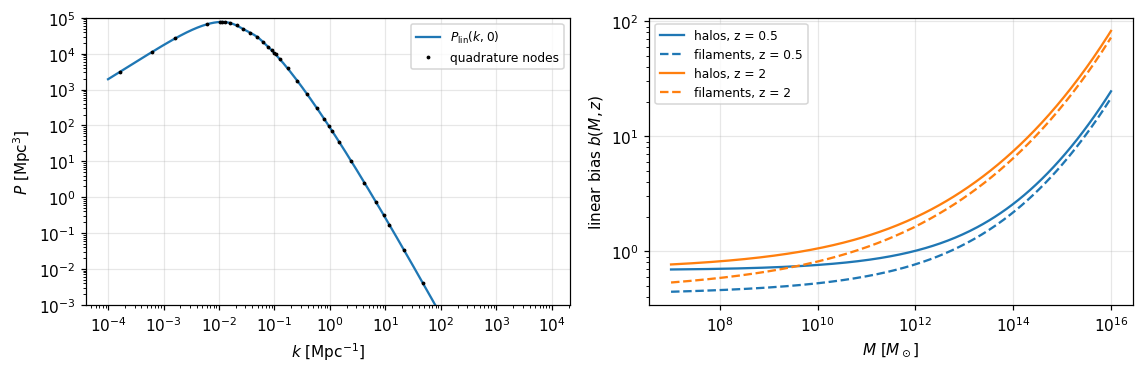

In [9]:
xi = F.xi_kperp_grid(cos)
print(f"xi_lin Limber term: {xi['kp'].size} transverse wavenumbers in "
      f"[{xi['kmin']:g}, {xi['kmax']:g}] /Mpc, shear harmonics m <= {xi['mmax']}")
kk = np.logspace(-4, 2, 400)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
ax[0].loglog(kk, F.P0(cos, kk), label=r"$P_{\rm lin}(k, 0)$")
ax[0].plot(xi["kp"], F.P0(cos, xi["kp"]), "k.", ms=3, label="quadrature nodes")
ax[0].set(xlabel=r"$k$ [Mpc$^{-1}$]", ylabel=r"$P$ [Mpc$^3$]", ylim=(1e-3, 1e5)); ax[0].legend(fontsize=8)
for zz in (0.5, 2.0):
    ax[1].semilogx(M, F.halo_bias(cos, M, zz), f"C{int(zz>1)}", label=f"halos, z = {zz:g}")
    ax[1].semilogx(M, F.fil_bias(cos, M, zz), f"C{int(zz>1)}--", label=f"filaments, z = {zz:g}")
ax[1].set(xlabel=r"$M$ [$M_\odot$]", ylabel="linear bias $b(M,z)$", yscale="log"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 7. Building the population and the exponent

Collecting everything, the Fourier-space master equation is
$$\partial_z\ln\tilde P(\boldsymbol k;z) = \ell(\boldsymbol k;z) + c_2(\boldsymbol k;z),\qquad
\ell = \sum_{p=h,f}\int\mathrm d\theta\,n_p\Big[\big\langle e^{i\boldsymbol k\cdot\boldsymbol Q_p}\big\rangle_{\rm sub} - 1 - i\boldsymbol k\cdot\langle\boldsymbol Q_p\rangle_{\rm sub}\Big],$$
$$\boxed{\;\ln\Phi_{\rm lens}(k_\kappa,k_\gamma) = \int_0^{z_s}\mathrm dz\,\ell(\boldsymbol k;z) + \Psi_2(\boldsymbol k)\;}$$
where $c_2$ is the integrand per unit redshift of $\Psi_2$. Both pieces are deterministic integrals.

**How it is evaluated.** `sgl_full.build_population` integrates every lens species over $(z, M, r, \psi, \varphi)$
and the subhalo quadrature nodes. It deposits the resulting jumps with their rates
$w = n\,\mathrm dz\,\mathrm d\theta$ into cells of a fine $(\kappa,\gamma)$ lattice, keeping each cell's exact weighted centroid
(`sgl_full.Cells`). The $z$ shells run in parallel processes and are merged in a fixed order, so the
result does not depend on `nproc`. The same pass accumulates the clustering responses $G_m$. `sgl_full.Lam`
then evaluates
$$\ln\Phi(k_\kappa,k_\gamma) = \sum_{\rm cells}w_b\Big[e^{ik_\kappa\kappa_b}J_0(k_\gamma\gamma_b) - 1 - ik_\kappa\kappa_b\Big] + \Psi_2 ,$$
using a separable evaluation (exact phases in $\kappa$, Chebyshev interpolation of $J_0 - 1$ in $\gamma$).

`pipeline.run(..., keep=True)` runs the full chain once and keeps every intermediate object, so the
remaining cells only inspect them.

In [10]:
t0 = time.time()
out, meta = pipeline.run(config.ZS, config.CONFIG, cosmo=config.COSMO, nproc=config.NPROC,
                         keep=True)
cells, info, lam = meta["cells"], meta["info"], meta["lam"]
print(f"one PDF at z_s = {config.ZS}: {time.time() - t0:.1f} s  "
      f"(build {out['t_stages']['build']:.1f} s, exponent {out['t_stages']['lam']:.2f} s, "
      f"inversion {out['t_stages']['invert']:.1f} s)")
print(f"occupied (kappa, gamma) cells: {lam.w0.size:,};  expected lens jumps per ray "
      f"sum w = {lam.w0.sum():.3e}")
print(f"mean convergence of the modelled lenses kbar = {info['kbar']:.4f} (subtracted: <kappa> = 0)")

one PDF at z_s = 1.0: 12.4 s  (build 10.1 s, exponent 0.25 s, inversion 1.9 s)
occupied (kappa, gamma) cells: 80,054;  expected lens jumps per ray sum w = 4.050e+06
mean convergence of the modelled lenses kbar = 0.0863 (subtracted: <kappa> = 0)


**The jump measure** is what the population build produces: the expected number of lens encounters
per ray in each $(\kappa,\gamma)$ cell. The lattice is logarithmic in $|\kappa|$, which can be negative for elliptical
lenses, and in $\gamma$. The faint lenses at the lower left are numerous but carry little variance. The
strong-lensing tail comes from rare encounters with $\kappa+\gamma\to1$.

**Exact cumulants.** For $n\ge2$ the Poisson part gives $\kappa_n = \sum_b w_b\,\kappa_b^n$, the cumulant formula of
Sec. 4 applied to the cells. The clustering term adds to the variance; `Lam.sigma()` returns the total
$\sigma_\kappa$.

sigma_kappa total = 0.03698
  independent lenses : Var = 1.2111e-03  (88.5%)
  clustering (Psi_2) : Var = 1.5672e-04  (11.5%)
  skewness of kappa from the jumps alone: 2.81


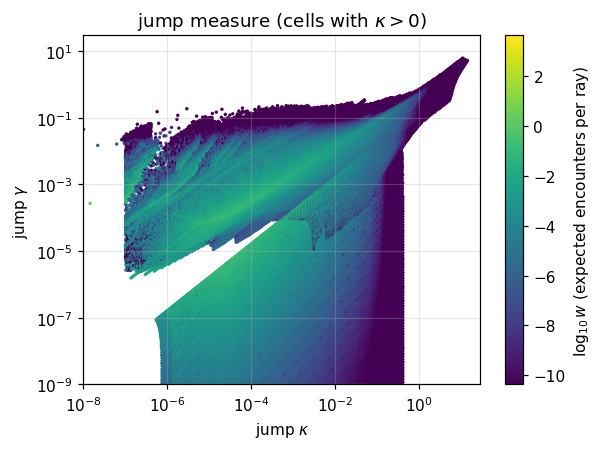

In [11]:
v_poisson = np.sum(lam.w0 * lam.k0**2)          # kappa_2 of the independent-lens term
k3_poisson = np.sum(lam.w0 * lam.k0**3)         # kappa_3
sig = lam.sigma()
print(f"sigma_kappa total = {sig:.5f}")
print(f"  independent lenses : Var = {v_poisson:.4e}  ({v_poisson/sig**2:.1%})")
print(f"  clustering (Psi_2) : Var = {sig**2 - v_poisson:.4e}  ({1 - v_poisson/sig**2:.1%})")
print(f"  skewness of kappa from the jumps alone: {k3_poisson / v_poisson**1.5:.2f}")

fig, ax = plt.subplots(figsize=(5.6, 4.2))
m = lam.k0 > 0
sc = ax.scatter(lam.k0[m], lam.g0[m], c=np.log10(lam.w0[m]), s=1.5, cmap="viridis",
                vmin=np.log10(lam.w0[m]).max() - 14)
ax.set(xscale="log", yscale="log", xlabel=r"jump $\kappa$", ylabel=r"jump $\gamma$",
       xlim=(1e-8, 30), ylim=(1e-9, 30), title=r"jump measure (cells with $\kappa > 0$)")
ax.plot([1e-8, 1], [1, 1e-8], alpha=0)
plt.colorbar(sc, label=r"$\log_{10} w$ (expected encounters per ray)")
fig.tight_layout(); plt.show()

**The characteristic function.** Along each axis, $\ln\Phi$ is compared with the Gaussian
(power-spectrum) approximation that keeps only the second cumulant: $-\tfrac12\sigma_\kappa^2k_\kappa^2$ along $k_\kappa$ and
$-\tfrac14\sigma_\gamma^2k_\gamma^2$ along $k_\gamma$ (with $\sigma_\gamma^2 = \langle\gamma_1^2+\gamma_2^2\rangle$). At small $k$ they agree. At large $k$ the jump
process decays more slowly: rare large jumps keep $|\Phi|$ from collapsing, and this is where the skewed
tail of $P(\mu)$ comes from. The imaginary part (the phase) is non-zero only along $k_\kappa$.

curvature of ln Phi at k=0: along k_kappa 1.3676e-03 (= sigma_kappa^2 = 1.3678e-03), along k_gamma 4.8262e-04 (= sigma_gamma^2/2)


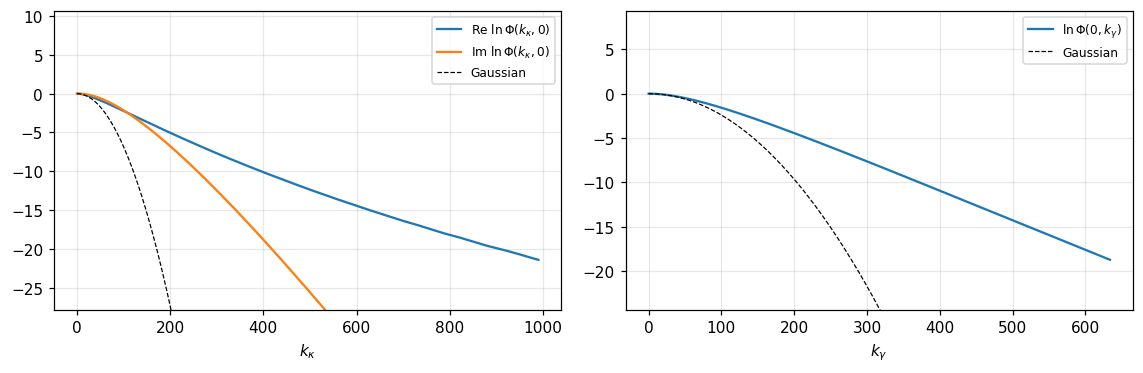

In [12]:
kk_ = np.linspace(0, meta["grid"]["k_k_max"], 400)
kg_ = np.linspace(0, meta["grid"]["k_g_max"], 400)
Lk = lam(kk_, np.zeros(1))[:, 0]
Lg = lam(np.zeros(1), kg_)[0, :]
# second-order (Gaussian) expansion along each axis, from the curvature of ln Phi at k = 0
h_ = 1e-2 / sig
c2k = -2 * lam(np.array([h_]), np.zeros(1))[0, 0].real / h_**2
c2g = -2 * lam(np.zeros(1), np.array([h_]))[0, 0].real / h_**2
print(f"curvature of ln Phi at k=0: along k_kappa {c2k:.4e} (= sigma_kappa^2 = {sig**2:.4e}),"
      f" along k_gamma {c2g:.4e} (= sigma_gamma^2/2)")
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
ax[0].plot(kk_, Lk.real, label=r"Re $\ln\Phi(k_\kappa, 0)$")
ax[0].plot(kk_, Lk.imag, label=r"Im $\ln\Phi(k_\kappa, 0)$")
ax[0].plot(kk_, -0.5 * c2k * kk_**2, "k--", lw=0.8, label="Gaussian")
ax[0].set(xlabel=r"$k_\kappa$", ylim=(1.3 * Lk.real.min(), 0.5 * abs(Lk.real.min())))
ax[1].plot(kg_, Lg.real, label=r"$\ln\Phi(0, k_\gamma)$")
ax[1].plot(kg_, -0.5 * c2g * kg_**2, "k--", lw=0.8, label="Gaussian")
ax[1].set(xlabel=r"$k_\gamma$", ylim=(1.3 * Lg.real.min(), 0.5 * abs(Lg.real.min())))
for a in ax: a.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 8. Inversion: from $\Phi$ to $P(\mu)$

By isotropy the joint density of $\boldsymbol X$ depends on the shear only through $\gamma$, so the inversion is
a Hankel transform in $k_\gamma$ followed by a Fourier transform in $k_\kappa$ (`sgl.P_vector_joint`, called from
`sgl_full.invert`):
$$p_3(\kappa,\gamma) = \frac{1}{(2\pi)^2}\int_{-\infty}^{\infty}\mathrm dk_\kappa\,e^{-ik_\kappa\kappa}\int_0^\infty\mathrm dk_\gamma\,k_\gamma J_0(k_\gamma\gamma)\,\Phi_{\rm lens}(k_\kappa,k_\gamma),$$
the density with respect to $\mathrm d\kappa\,\mathrm d\gamma_1\mathrm d\gamma_2$. The $k$ grid is chosen adaptively: the step is set by the support of
the density (to avoid aliasing), and the reach goes to $|\Phi|\le10^{-8}$. The $k_\gamma$ trapezoid gets its
Euler-Maclaurin end-point corrections. The magnification is
$$\mu = \frac{1}{(1-\kappa)^2 - \gamma^2}.$$
On the weak, positive-parity branch the level set of $\mu$ is a circle of radius $\gamma = \sqrt{(1-\kappa)^2 - \mu^{-1}}$ in the
shear plane, so the image-plane PDF is a line integral of $p_3$,
$$\frac{\mathrm dP_I}{\mathrm d\mu} = \frac{\pi}{\mu^2}\int_{-\infty}^{1-\mu^{-1/2}}\mathrm d\kappa\;p_3\Big(\kappa,\sqrt{(1-\kappa)^2-\mu^{-1}}\Big),\qquad
\frac{\mathrm dP_S}{\mathrm d\mu} = \frac{\mu^{-1}\,\mathrm dP_I/\mathrm d\mu}{\int_0^\infty\mathrm d\mu'\,\mu'^{-1}\,\mathrm dP_I/\mathrm d\mu'} .$$
The source-plane PDF weights by the area factor $1/\mu$. The $(\kappa,\gamma)$ box extends to $\kappa\le0.99$, $\gamma\le0.8$ so that the
strong-lensing tail is resolved.

On the log plots, the oscillations below the empty-beam edge (small negative $\ln\mu$) are the numerical floor
of the Fourier inversion. They stay below about $10^{-5}$ of the peak at $z_s = 1$ and $3\times10^{-5}$ at $z_s = 0.5$. The
real density there is zero: the edge is set by rays with almost no lenses.

k grid: 1670 x 2150 points to k_kappa = 990.2, k_gamma = 633.7  (|Phi| at the cuts 5.1e-10, 7.4e-09)
(kappa, gamma) box: kappa in [-0.222, 0.990], gamma <= 0.800, 788 x 261 points


re-inversion vs run():  max|dP| = 0.0


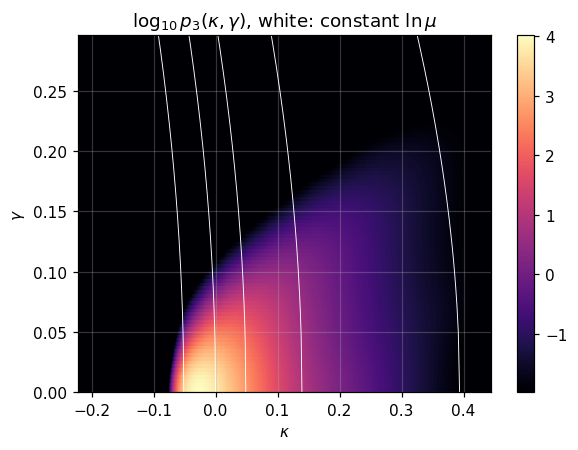

In [13]:
g = meta["grid"]
print(f"k grid: {g['nk_k']} x {g['nk_g']} points to k_kappa = {g['k_k_max']:.1f}, "
      f"k_gamma = {g['k_g_max']:.1f}  (|Phi| at the cuts {g['phi_at_k_cut']:.1e}, {g['phi_at_g_cut']:.1e})")
print(f"(kappa, gamma) box: kappa in [{g['kap_min']:.3f}, {g['kap_max']:.3f}], gamma <= {g['gam_max']:.3f},"
      f" {g['n_kap']} x {g['n_gam']} points")

# re-running the inversion step alone on the kept exponent reproduces the chain exactly
xi_chk, P_chk, _ = F.invert(lam, sig, xi_out=np.asarray(out["xi"]), phi_tol=1e-8)
print("re-inversion vs run():  max|dP| =", np.max(np.abs(P_chk - np.asarray(out["P_s"]))))

kap, gam, P3 = meta["kap"], meta["gam"], meta["P3"]
fig, ax = plt.subplots(figsize=(5.6, 4.2))
im = ax.pcolormesh(kap, gam, np.log10(np.clip(P3.T, 1e-6 * P3.max(), None)), shading="auto",
                   cmap="magma")
for lm in (-0.1, 0.0, 0.1, 0.3, 1.0):
    kl = np.linspace(kap[0], 1 - np.exp(-lm / 2), 300)
    ax.plot(kl, np.sqrt(np.clip((1 - kl)**2 - np.exp(-lm), 0, None)), "w-", lw=0.6)
ax.set(xlabel=r"$\kappa$", ylabel=r"$\gamma$", xlim=(kap[0], min(kap[-1], 12 * sig)),
       ylim=(0, min(gam[-1], 8 * sig)), title=r"$\log_{10}p_3(\kappa,\gamma)$, white: constant $\ln\mu$")
plt.colorbar(im); fig.tight_layout(); plt.show()

z_s = 1.0:  sigma_kappa = 0.03698,  sigma_DL/D_L = 0.03396
ln mu moments (full support): mean -0.00363, var 5.0219e-03, skew 2.633
ln mu moments (|ln mu| <= 1) : mean -0.00371, var 4.9264e-03, skew 2.363


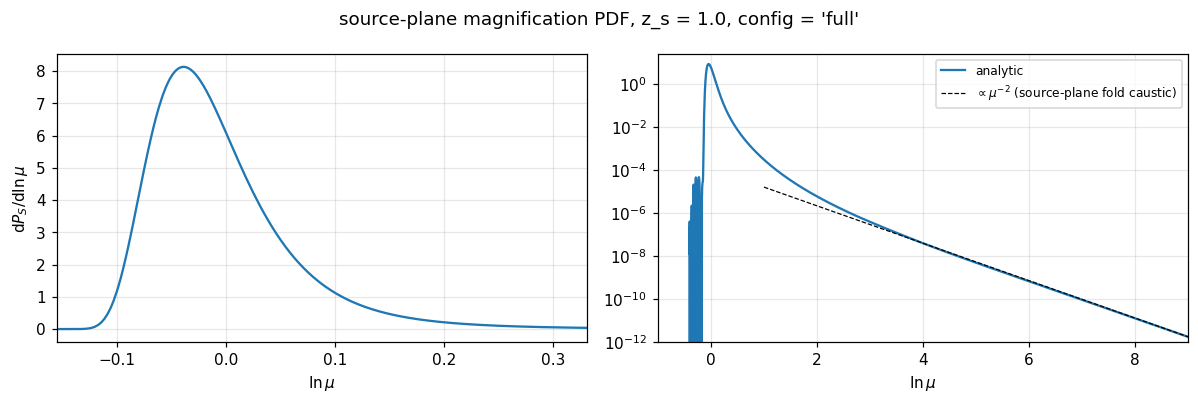

In [14]:
xi_b, P_b = np.asarray(out["xi"]), np.asarray(out["P_s"])
xi_t, P_t = np.asarray(out["xi_tail"]), np.asarray(out["P_s_tail"])
cm = pipeline.clipped_moments(xi_b, P_b)
print(f"z_s = {config.ZS}:  sigma_kappa = {out['sigma_kappa']:.5f},  sigma_DL/D_L = {out['sigmaDL']:.5f}")
print(f"ln mu moments (full support): mean {out['mean']:+.5f}, var {out['var']:.4e}, skew {out['skew']:.3f}")
print(f"ln mu moments (|ln mu| <= 1) : mean {cm['mean']:+.5f}, var {cm['var']:.4e}, skew {cm['skew']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7))
ax[0].plot(xi_b, P_b, "C0")
ax[0].set(xlabel=r"$\ln\mu$", ylabel=r"$\mathrm{d}P_S/\mathrm{d}\ln\mu$",
          xlim=(xi_b[P_b > 1e-4 * P_b.max()][0] - 0.02, 4 * np.sqrt(cm["var"]) + 0.05))
ax[1].semilogy(np.r_[xi_b, xi_t], np.r_[P_b, P_t], "C0", label="analytic")
mu_ = np.exp(xi_t)
ax[1].semilogy(xi_t, P_t[np.searchsorted(xi_t, 4.0)] * (mu_ / np.exp(4.0))**-2, "k--", lw=0.8,
               label=r"$\propto\mu^{-2}$ (source-plane fold caustic)")
ax[1].set(xlabel=r"$\ln\mu$", ylim=(1e-12, 3 * P_b.max()), xlim=(xi_b[0], 9)); ax[1].legend(fontsize=8)
fig.suptitle(f"source-plane magnification PDF, z_s = {config.ZS}, config = {config.CONFIG!r}")
fig.tight_layout(); plt.show()

## 9. Source redshift and cosmology

One call to `pipeline.run(zs, cfg, cosmo=...)` per PDF. The PDF widens and becomes less skewed with
source redshift as more lenses add up along the line of sight. A larger $\sigma_8$ raises the abundance of massive
halos and their concentrations, which widens the distribution and lifts its tail. The bundled reference PDFs
(`tests/reference/`, Planck cosmology) are overplotted as a regression check for the default cosmology.

  z_s  sigma_k        var   skew  sigma_DL   time  ref max|dP|/peak


  0.5  0.01655 1.0313e-03   3.71   0.01558  13.2s  0.0e+00


    1  0.03698 4.9264e-03   2.36   0.03396  13.6s  0.0e+00


    3  0.09120 2.6723e-02   1.30   0.07951  19.7s  0.0e+00


   10  0.14785 6.1653e-02   0.90   0.12296  24.5s  0.0e+00


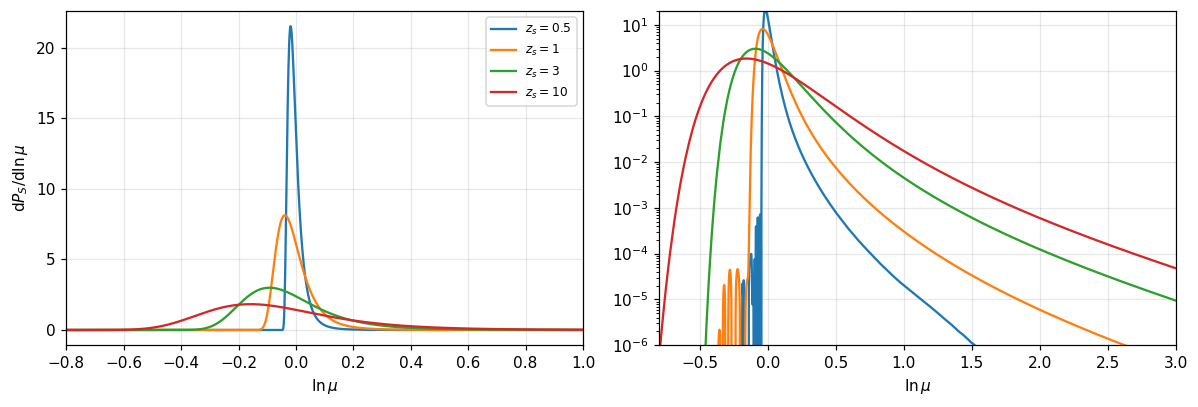

In [15]:
import json
runs = {}
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
print(f"{'z_s':>5s} {'sigma_k':>8s} {'var':>10s} {'skew':>6s} {'sigma_DL':>9s} {'time':>6s}  ref max|dP|/peak")
for zs in config.ZS_LIST:
    o, _ = pipeline.run(zs, config.CONFIG, cosmo=config.COSMO, nproc=config.NPROC,
                        xi_tail=np.linspace(1.005, 9.0, 1600))
    runs[zs] = o
    x_, P_ = np.r_[o["xi"], o["xi_tail"]], np.r_[o["P_s"], o["P_s_tail"]]
    cmz = pipeline.clipped_moments(np.asarray(o["xi"]), np.asarray(o["P_s"]))
    ref = REPO / "tests" / "reference" / f"pdf_zs{zs:g}.json"
    dref = "--"
    if ref.is_file() and config.COSMO == pipeline.P and config.CONFIG == "full":
        r = json.loads(ref.read_text())
        dref = f"{np.max(np.abs(np.asarray(r['P_s']) - np.asarray(o['P_s']))) / max(r['P_s']):.1e}"
    print(f"{zs:5g} {o['sigma_kappa']:8.5f} {cmz['var']:10.4e} {cmz['skew']:6.2f} {o['sigmaDL']:9.5f} "
          f"{o['seconds']:5.1f}s  {dref}")
    for a in ax:
        a.plot(x_, P_, label=f"$z_s = {zs:g}$")
ax[0].set(xlabel=r"$\ln\mu$", ylabel=r"$\mathrm{d}P_S/\mathrm{d}\ln\mu$", xlim=(-0.8, 1.0))
ax[1].set(xlabel=r"$\ln\mu$", yscale="log", ylim=(1e-6, 20), xlim=(-0.8, 3))
ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()

z_s = 1.0
 sigma_8  sigma_k  clipped var   skew


   0.750  0.03429   4.3045e-03   2.33


   0.811  0.03698   4.9264e-03   2.36


   0.870  0.03952   5.5306e-03   2.38


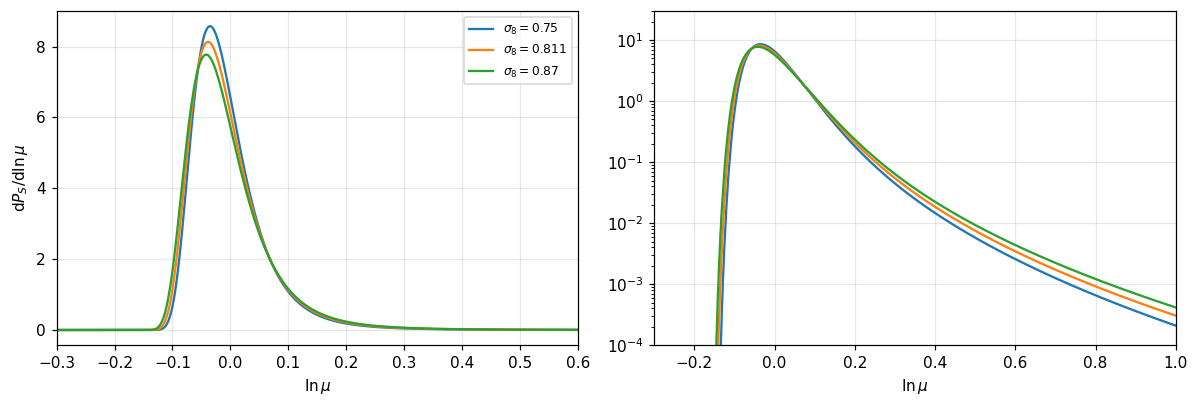

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
print(f"z_s = {config.ZS}")
print(f"{'sigma_8':>8s} {'sigma_k':>8s} {'clipped var':>12s} {'skew':>6s}")
base = None
for s8 in config.S8_SCAN:
    o, _ = pipeline.run(config.ZS, config.CONFIG, cosmo={**config.COSMO, "s8": s8},
                        nproc=config.NPROC)
    x_, P_ = np.asarray(o["xi"]), np.asarray(o["P_s"])
    cmz = pipeline.clipped_moments(x_, P_)
    print(f"{s8:8.3f} {o['sigma_kappa']:8.5f} {cmz['var']:12.4e} {cmz['skew']:6.2f}")
    ax[0].plot(x_, P_, label=rf"$\sigma_8 = {s8:g}$")
    ax[1].semilogy(x_, P_, label=rf"$\sigma_8 = {s8:g}$")
ax[0].set(xlabel=r"$\ln\mu$", ylabel=r"$\mathrm{d}P_S/\mathrm{d}\ln\mu$",
          xlim=(-0.3 * config.ZS**0.5, 0.6 * config.ZS**0.5))
ax[1].set(xlabel=r"$\ln\mu$", ylim=(1e-4, 30), xlim=ax[0].get_xlim()[0:1] + (1.0,))
ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()

## Summary

For a given cosmology and source redshift, the solver returns the source-plane magnification
distribution of the stochastic lens model (halos with virial truncation, ellipticity, filaments,
decorated-host subhalos, linear $\xi_{\rm lin}$ clustering). It samples no lens configuration and draws no
random number: the master equation's solution
$\ln\Phi_{\rm lens} = \int_0^{z_s}\mathrm dz\,\ell + \Psi_2$ is a deterministic integral over the lens population, and one Hankel-Fourier
inversion gives $P(\mu)$. One PDF takes about 10-20 s.

**Approximations to keep in mind:**
- Born approximation (distortions add) and the weak, positive-parity branch of $\mu$;
- clustering is truncated at the two-point term, with linear bias, $\xi_{\rm lin}$ and Limber;
- in the subhalo average the total shear magnitude is replaced by its conditional rms;
- the model is truncated at $r_{\rm vir}$ and uses $\xi_{\rm lin}$, unlike the engine's untruncated halos and lognormal 1D field. At
  $z_s\lesssim1$ it is therefore a few per cent narrower than the engine's Monte Carlo by construction.

**To explore:** edit `config.py` (`ZS`, `COSMO`, `CONFIG`, `ZS_LIST`, `S8_SCAN`, the example lens) and rerun
`python scripts/build_notebook.py`. To get a single PDF without the notebook:
`python run_pdf.py --zs 2 --s8 0.78 --Om 0.30`.